# Fruits-360 Image Classification on Kaggle

Notebook final for the machine learning course project.

**Dataset:** https://www.kaggle.com/datasets/moltean/fruits

**How to run on Kaggle:**
1. Add Data -> `moltean/fruits`
2. Settings -> Accelerator -> GPU, if available
3. Run All

Outputs are saved to `/kaggle/working`.

In [1]:

import os
import random
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)


2026-05-04 03:52:10.138719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777866730.362462      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777866730.427851      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777866730.930892      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777866730.930929      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777866730.930932      57 computation_placer.cc:177] computation placer alr

In [2]:

# =========================================================
# 1. CAU HINH CHUNG
# =========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Neu Kaggle bi loi RAM/GPU, giam MAX_CLASSES xuong 10 va BATCH_SIZE xuong 16.
IMG_SIZE = (100, 100)
BATCH_SIZE = 32
MAX_CLASSES = 20          # Theo yeu cau do an: chon 10-20 lop
EPOCHS_BASELINE = 6
EPOCHS_CUSTOM_CNN = 8
EPOCHS_MOBILENET = 8
VALIDATION_SPLIT = 0.20

IS_KAGGLE = Path('/kaggle').exists()
WORK_DIR = Path('/kaggle/working') if IS_KAGGLE else Path.cwd() / 'working_outputs'
PLOT_DIR = WORK_DIR / 'plots'
MODEL_DIR = WORK_DIR / 'models'
REPORT_DIR = WORK_DIR / 'reports'

for d in [WORK_DIR, PLOT_DIR, MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('=' * 70)
print('TensorFlow version:', tf.__version__)
print('Running on Kaggle:', IS_KAGGLE)
print('Working directory:', WORK_DIR)
print('=' * 70)

# Thiet lap GPU memory growth de giam nguy co loi chiem het VRAM.
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    print('GPU detected:', len(gpus))
except Exception as e:
    print('GPU setup skipped:', repr(e))

TensorFlow version: 2.19.0
Running on Kaggle: True
Working directory: /kaggle/working
GPU detected: 1


In [3]:

# =========================================================
# 2. TU DONG TIM DATASET FRUITS-360 TREN KAGGLE
# =========================================================
def count_image_files(folder: Path) -> int:
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
    if not folder.exists():
        return 0
    return sum(1 for p in folder.rglob('*') if p.suffix.lower() in exts)


def find_fruits360_root() -> Path:
    """Tim thu muc goc co chua Training va Test cua Fruits-360.
    Ho tro nhieu cau truc thu muc cua dataset moltean/fruits tren Kaggle.
    """
    search_bases = []
    if IS_KAGGLE:
        search_bases.append(Path('/kaggle/input'))
    search_bases += [Path.cwd(), Path.cwd() / 'data', Path('/mnt/data')]

    candidates = []
    for base in search_bases:
        if not base.exists():
            continue
        for train_dir in base.rglob('Training'):
            test_dir = train_dir.parent / 'Test'
            if test_dir.exists():
                n_train = count_image_files(train_dir)
                n_test = count_image_files(test_dir)
                if n_train > 0 and n_test > 0:
                    candidates.append((train_dir.parent, n_train, n_test))

    if not candidates:
        raise FileNotFoundError(
            "Khong tim thay dataset Fruits-360. Tren Kaggle, hay vao Add Data va them dataset 'moltean/fruits'. "
            "Dataset phai co hai thu muc Training va Test."
        )

    # Uu tien thu muc co nhieu anh nhat va co chu 'fruit' trong path.
    candidates = sorted(
        candidates,
        key=lambda x: (('fruit' not in str(x[0]).lower()), -(x[1] + x[2]), len(str(x[0]))),
    )
    return candidates[0][0]


DATA_ROOT = find_fruits360_root()
TRAIN_DIR = DATA_ROOT / 'Training'
TEST_DIR = DATA_ROOT / 'Test'

print('Dataset root:', DATA_ROOT)
print('Training images:', count_image_files(TRAIN_DIR))
print('Test images:', count_image_files(TEST_DIR))

Dataset root: /kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360
Training images: 135071
Test images: 45008


In [4]:

# =========================================================
# 3. CHON 10-20 CLASS DE CHAY ON DINH
# =========================================================
all_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
if not all_classes:
    raise ValueError('Thu muc Training khong co class nao.')

selected_classes = all_classes[: min(MAX_CLASSES, len(all_classes))]
NUM_CLASSES = len(selected_classes)

if NUM_CLASSES < 2:
    raise ValueError('Can it nhat 2 class de huan luyen mo hinh phan loai.')

print('Original number of classes:', len(all_classes))
print('Selected number of classes:', NUM_CLASSES)
print('Selected classes:', selected_classes)

# Luu danh sach class de dung cho bao cao va demo.
with open(WORK_DIR / 'selected_classes.json', 'w', encoding='utf-8') as f:
    json.dump(selected_classes, f, ensure_ascii=False, indent=2)


Original number of classes: 257
Selected number of classes: 20
Selected classes: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20', 'Apple 21', 'Apple 22', 'Apple 23', 'Apple 5', 'Apple 6', 'Apple 7', 'Apple 8', 'Apple 9', 'Apple Braeburn 1', 'Apple Crimson Snow 1']



EDA - class distribution:
                   class  n_images_train  n_images_test  total  train_ratio
0              Almonds 1             232             77    309     0.750809
1               Apple 10             699            231    930     0.751613
2               Apple 11             430            142    572     0.751748
3               Apple 12             466            154    620     0.751613
4               Apple 13             699            235    934     0.748394
5               Apple 14             466            154    620     0.751613
6               Apple 17             610            201    811     0.752158
7               Apple 18             724            240    964     0.751037
8               Apple 19             729            241    970     0.751546
9               Apple 20             702            234    936     0.750000
10              Apple 21             488            162    650     0.750769
11              Apple 22             696            231    92

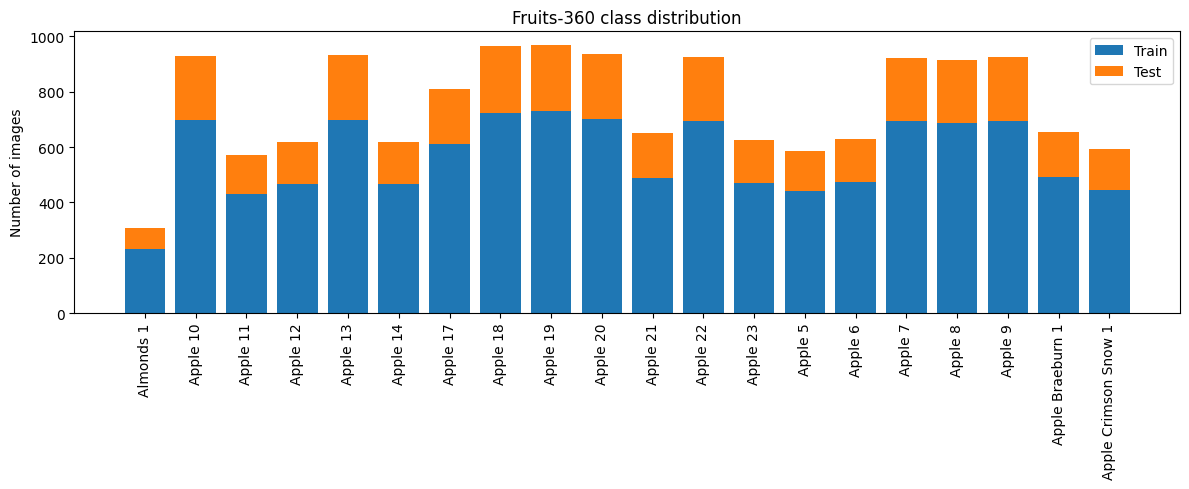

In [5]:


# =========================================================
# 4. EDA: THONG KE SO LUONG ANH THEO CLASS
# =========================================================
def count_images_by_class(directory: Path, classes: list[str]) -> pd.DataFrame:
    rows = []
    for cls in classes:
        cls_dir = directory / cls
        n = count_image_files(cls_dir)
        rows.append({'class': cls, 'n_images': n})
    return pd.DataFrame(rows)


train_counts = count_images_by_class(TRAIN_DIR, selected_classes)
test_counts = count_images_by_class(TEST_DIR, selected_classes)
eda_table = train_counts.merge(test_counts, on='class', suffixes=('_train', '_test'))
eda_table['total'] = eda_table['n_images_train'] + eda_table['n_images_test']
eda_table['train_ratio'] = eda_table['n_images_train'] / eda_table['total']
eda_table.to_csv(REPORT_DIR / 'eda_class_distribution.csv', index=False)

print('\nEDA - class distribution:')
print(eda_table)

plt.figure(figsize=(12, 5))
plt.bar(eda_table['class'], eda_table['n_images_train'], label='Train')
plt.bar(
    eda_table['class'],
    eda_table['n_images_test'],
    bottom=eda_table['n_images_train'],
    label='Test',
)
plt.xticks(rotation=90)
plt.ylabel('Number of images')
plt.title('Fruits-360 class distribution')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'class_distribution.png', dpi=200)
plt.show()

In [6]:


# =========================================================
# 5. LOAD DATASET BANG TF.DATA
# =========================================================
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=selected_classes,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=selected_classes,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=selected_classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE

Found 11335 files belonging to 20 classes.
Using 9068 files for training.


I0000 00:00:1777867941.272788      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 11335 files belonging to 20 classes.
Using 2267 files for validation.
Found 3761 files belonging to 20 classes.


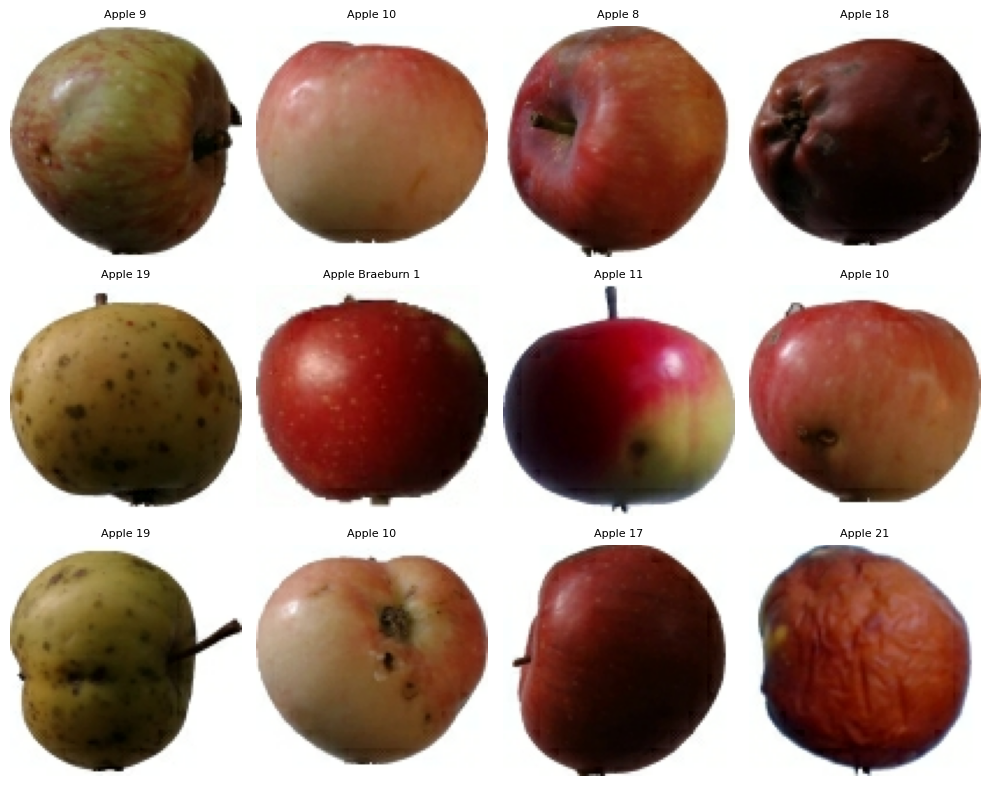

In [7]:

# Khong dung cache() de tranh loi RAM tren Kaggle. Prefetch van giup train nhanh hon.
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# Ve anh mau cho bao cao.
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    n_show = min(12, images.shape[0])
    for i in range(n_show):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(np.argmax(labels[i].numpy()))], fontsize=8)
        plt.axis('off')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'sample_images.png', dpi=200)
plt.show()

In [8]:


# =========================================================
# 6. HAM HO TRO TRAIN, VE BIEU DO, DANH GIA
# =========================================================
def compile_model(model: keras.Model, learning_rate: float = 1e-3) -> keras.Model:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


callbacks_common = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6
    ),
]

In [9]:


def plot_history(history: keras.callbacks.History, model_name: str) -> None:
    hist = pd.DataFrame(history.history)
    hist.to_csv(REPORT_DIR / f'history_{model_name}.csv', index=False)

    plt.figure(figsize=(7, 5))
    plt.plot(hist['accuracy'], label='train_accuracy')
    plt.plot(hist['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy - {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'accuracy_{model_name}.png', dpi=200)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(hist['loss'], label='train_loss')
    plt.plot(hist['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss - {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'loss_{model_name}.png', dpi=200)
    plt.show()

In [10]:



def get_predictions(model: keras.Model, dataset: tf.data.Dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)


In [11]:



def evaluate_and_save(model: keras.Model, model_name: str) -> dict:
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    y_true, y_pred = get_predictions(model, test_ds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    report_text = classification_report(
        y_true, y_pred, target_names=class_names, zero_division=0
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    with open(REPORT_DIR / f'classification_report_{model_name}.txt', 'w', encoding='utf-8') as f:
        f.write(report_text)
    pd.DataFrame(report_dict).transpose().to_csv(
        REPORT_DIR / f'classification_report_{model_name}.csv'
    )

    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        REPORT_DIR / f'confusion_matrix_{model_name}.csv'
    )

    plt.figure(figsize=(12, 10))
    plt.imshow(cm)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.xticks(range(NUM_CLASSES), class_names, rotation=90, fontsize=7)
    plt.yticks(range(NUM_CLASSES), class_names, fontsize=7)
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'confusion_matrix_{model_name}.png', dpi=200)
    plt.show()

    model.save(MODEL_DIR / f'{model_name}.keras')

    return {
        'model': model_name,
        'test_loss': float(test_loss),
        'accuracy': float(test_acc),
        'precision_weighted': float(precision),
        'recall_weighted': float(recall),
        'f1_weighted': float(f1),
    }


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,292 (118.33 KB)

 Trainable params: 30,292 (118.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6


I0000 00:00:1777867947.508515     134 service.cc:152] XLA service 0x7de25c009230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777867947.508558     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777867947.877630     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


  9/284 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0418 - loss: 2.9931

I0000 00:00:1777867950.509788     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


284/284 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.1378 - loss: 2.7056 - val_accuracy: 0.5774 - val_loss: 1.3347 - learning_rate: 0.0010
Epoch 2/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5281 - loss: 1.3054 - val_accuracy: 0.7164 - val_loss: 0.8167 - learning_rate: 0.0010
Epoch 3/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6656 - loss: 0.9071 - val_accuracy: 0.7503 - val_loss: 0.7063 - learning_rate: 0.0010
Epoch 4/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7218 - loss: 0.7526 - val_accuracy: 0.8077 - val_loss: 0.5425 - learning_rate: 0.0010
Epoch 5/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7627 - loss: 0.6199 - val_accuracy: 0.8443 - val_loss: 0.4574 - learning_rate: 0.0010
Epoch 6/6
284/284 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8000 - loss: 0.5310 - val_accuracy: 0.8902 - val_loss: 0.3241 - learning_rate: 0.0010


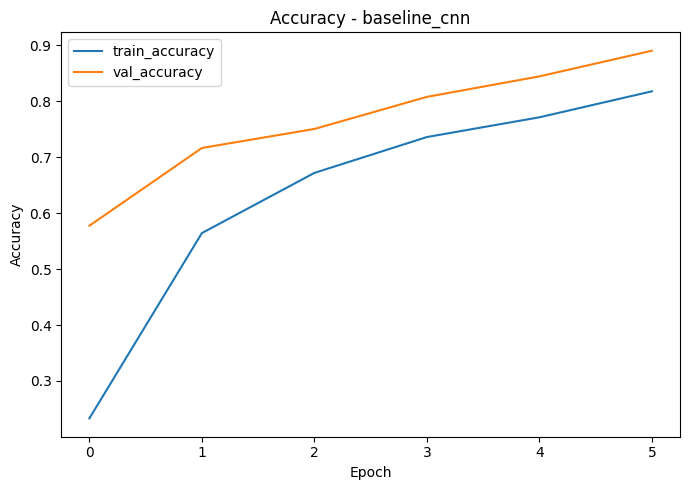

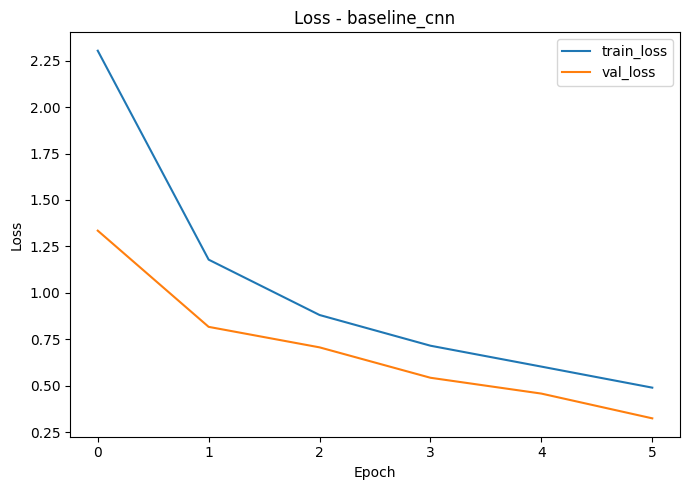

In [12]:


# =========================================================
# 7. MODEL 1: BASELINE CNN
# =========================================================
def build_baseline_cnn() -> keras.Model:
    model = keras.Sequential(
        [
            layers.Input(shape=IMG_SIZE + (3,)),
            layers.Rescaling(1.0 / 255),
            layers.Conv2D(32, 3, activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, activation='relu', padding='same'),
            layers.MaxPooling2D(),
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.30),
            layers.Dense(NUM_CLASSES, activation='softmax'),
        ],
        name='Baseline_CNN',
    )
    return compile_model(model, learning_rate=1e-3)


baseline_cnn = build_baseline_cnn()
baseline_cnn.summary()
history_baseline = baseline_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    callbacks=callbacks_common,
)
plot_history(history_baseline, 'baseline_cnn')


Model: "Custom_CNN_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             

 Total params: 326,964 (1.25 MB)

 Trainable params: 326,068 (1.24 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/8


E0000 00:00:1777867987.741685      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Custom_CNN_Augmentation_1/dropout_1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


284/284 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.6711 - loss: 1.0612 - val_accuracy: 0.0410 - val_loss: 11.1063 - learning_rate: 0.0010
Epoch 2/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.9389 - loss: 0.1821 - val_accuracy: 0.5161 - val_loss: 2.1542 - learning_rate: 0.0010
Epoch 3/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.9698 - loss: 0.0907 - val_accuracy: 0.7794 - val_loss: 1.1540 - learning_rate: 0.0010
Epoch 4/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.9767 - loss: 0.0698 - val_accuracy: 0.6612 - val_loss: 2.2940 - learning_rate: 0.0010
Epoch 5/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.9721 - loss: 0.0841 - val_accuracy: 0.8350 - val_loss: 0.6408 - learning_rate: 0.0010
Epoch 6/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.9848 - loss: 0.0525 - val_accuracy: 0.9841 - val_loss: 0.0428 - learning_rate: 0.0010
Epoch 7/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.9836 - loss: 0.0491 - va

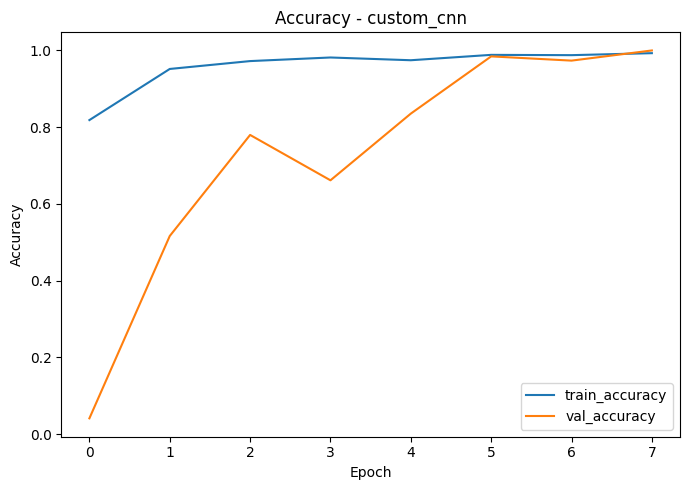

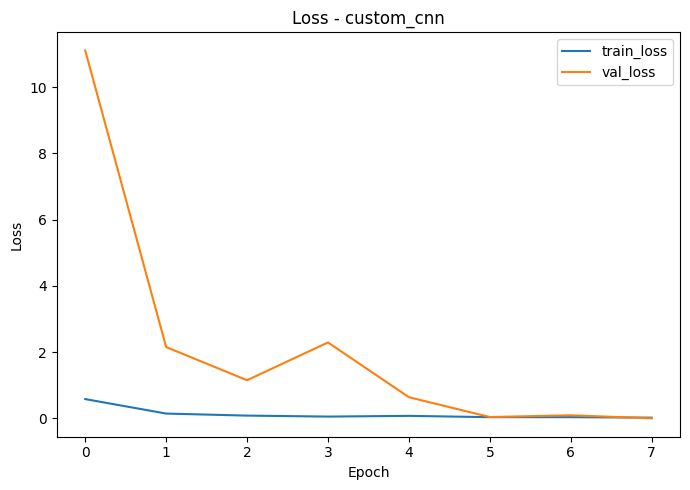

In [13]:

# =========================================================
# 8. MODEL 2: CUSTOM CNN + AUGMENTATION
# =========================================================
def build_custom_cnn() -> keras.Model:
    data_augmentation = keras.Sequential(
        [
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
        ],
        name='data_augmentation',
    )

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.20)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='Custom_CNN_Augmentation')
    return compile_model(model, learning_rate=1e-3)


custom_cnn = build_custom_cnn()
custom_cnn.summary()
history_custom = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CUSTOM_CNN,
    callbacks=callbacks_common,
)
plot_history(history_custom, 'custom_cnn')

/tmp/ipykernel_57/4244931122.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded with ImageNet pretrained weights.


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 100, 100, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │        25,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,283,604 (8.71 MB)

 Trainable params: 25,620 (100.08 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.5606 - loss: 1.6078 - val_accuracy: 0.9629 - val_loss: 0.1310 - learning_rate: 0.0010
Epoch 2/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9390 - loss: 0.1981 - val_accuracy: 0.9899 - val_loss: 0.0609 - learning_rate: 0.0010
Epoch 3/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9635 - loss: 0.1192 - val_accuracy: 0.9934 - val_loss: 0.0465 - learning_rate: 0.0010
Epoch 4/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9732 - loss: 0.0860 - val_accuracy: 0.9947 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 5/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9848 - loss: 0.0568 - val_accuracy: 0.9956 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 6/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9867 - loss: 0.0450 - val_accuracy: 0.9996 - val_loss: 0.0192 - learning_rate: 0.0010
Epoch 7/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9903 - loss: 0.0393 -

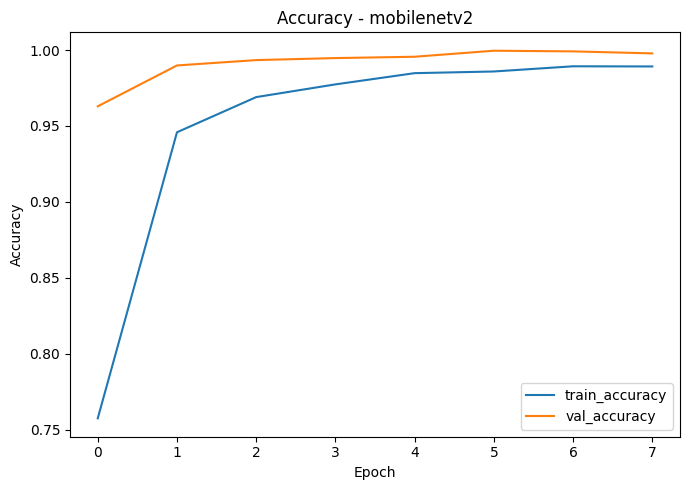

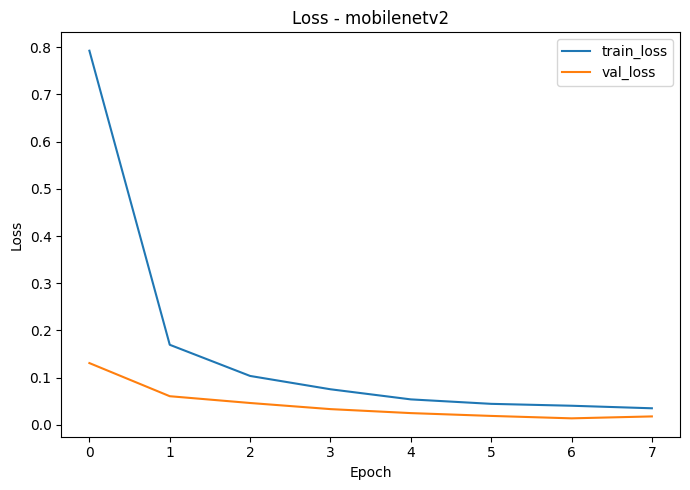

In [14]:

# =========================================================
# 9. MODEL 3: MOBILENETV2
# =========================================================
def build_mobilenetv2() -> keras.Model:
    # Tren Kaggle neu internet bi tat va chua co ImageNet weights, code se tu dong fallback sang weights=None.
    try:
        base_model = keras.applications.MobileNetV2(
            input_shape=IMG_SIZE + (3,),
            include_top=False,
            weights='imagenet',
        )
        print('MobileNetV2 loaded with ImageNet pretrained weights.')
    except Exception as e:
        print('Cannot load ImageNet weights. Fallback to weights=None. Reason:', repr(e))
        base_model = keras.applications.MobileNetV2(
            input_shape=IMG_SIZE + (3,),
            include_top=False,
            weights=None,
        )

    base_model.trainable = False
    preprocess = keras.applications.mobilenet_v2.preprocess_input

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.05)(x)
    x = preprocess(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2')
    return compile_model(model, learning_rate=1e-3)


mobilenetv2 = build_mobilenetv2()
mobilenetv2.summary()
history_mobilenet = mobilenetv2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_MOBILENET,
    callbacks=callbacks_common,
)
plot_history(history_mobilenet, 'mobilenetv2')

Epoch 1/3
284/284 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.6112 - loss: 1.4213 - val_accuracy: 0.9951 - val_loss: 0.0202 - learning_rate: 1.0000e-05
Epoch 2/3
284/284 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9016 - loss: 0.3276 - val_accuracy: 0.9938 - val_loss: 0.0214 - learning_rate: 1.0000e-05
Epoch 3/3
284/284 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9589 - loss: 0.1613 - val_accuracy: 0.9956 - val_loss: 0.0200 - learning_rate: 1.0000e-05


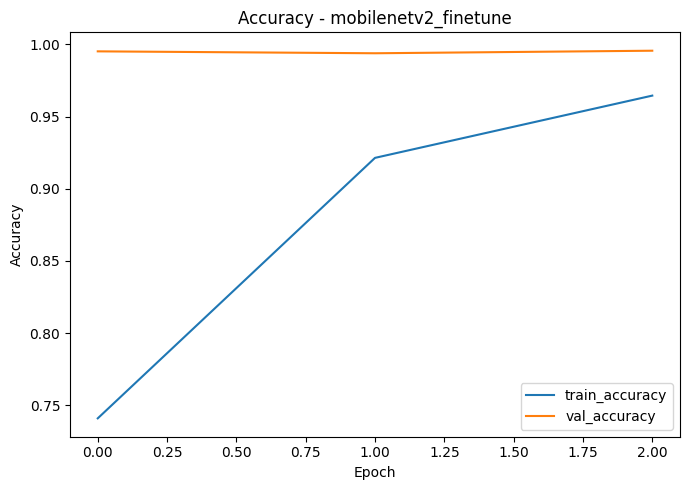

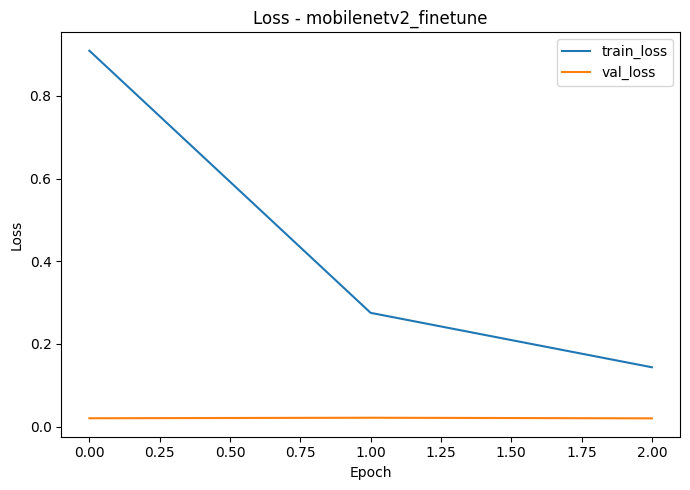

In [15]:


# Fine-tune nhe 20 layer cuoi neu base model ton tai. Phan nay giup cai thien ket qua nhung van an toan.
try:
    base_model = None
    for layer in mobilenetv2.layers:
        if isinstance(layer, keras.Model) and 'mobilenetv2' in layer.name.lower():
            base_model = layer
            break

    if base_model is not None:
        base_model.trainable = True
        for layer in base_model.layers[:-20]:
            layer.trainable = False

        mobilenetv2 = compile_model(mobilenetv2, learning_rate=1e-5)
        history_mobilenet_ft = mobilenetv2.fit(
            train_ds,
            validation_data=val_ds,
            epochs=3,
            callbacks=callbacks_common,
        )
        plot_history(history_mobilenet_ft, 'mobilenetv2_finetune')
except Exception as e:
    print('MobileNetV2 fine-tuning skipped:', repr(e))

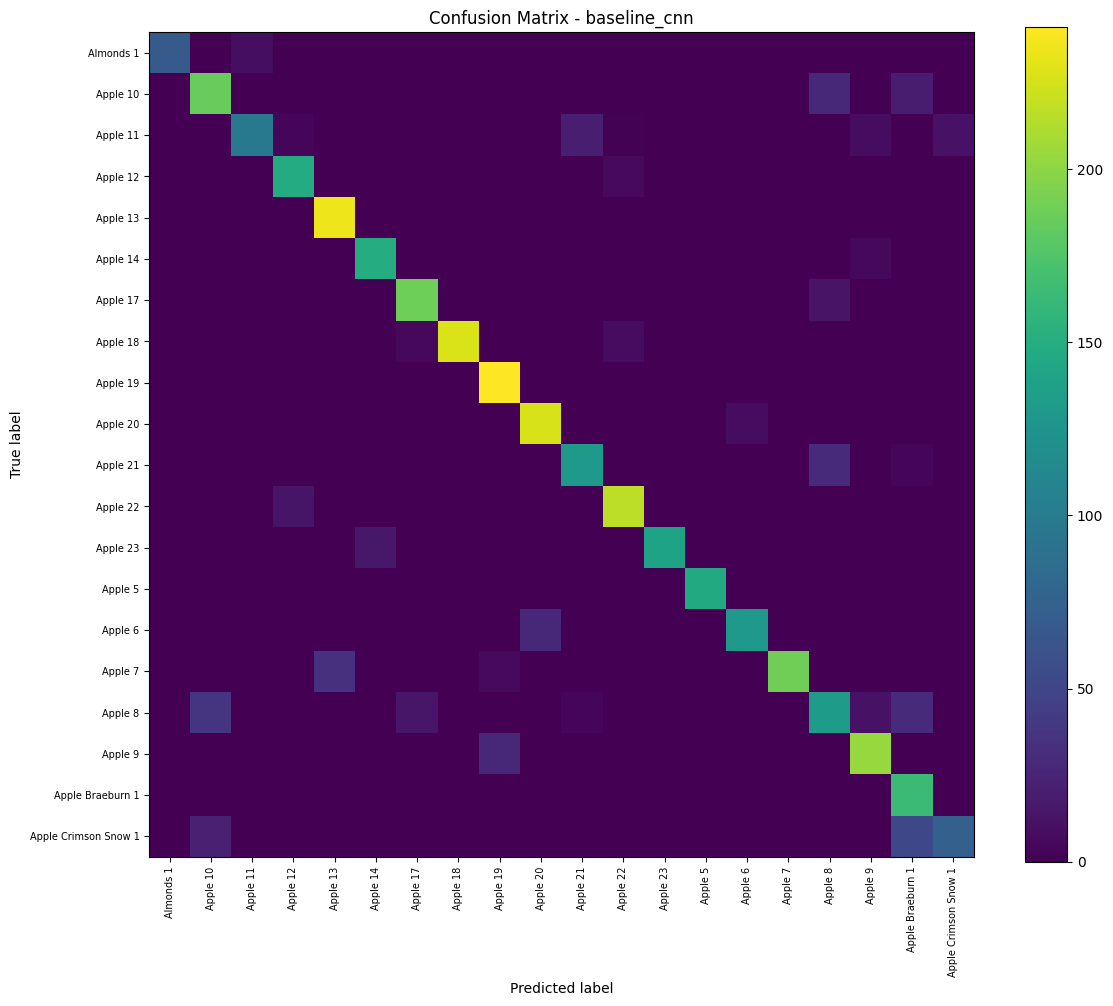

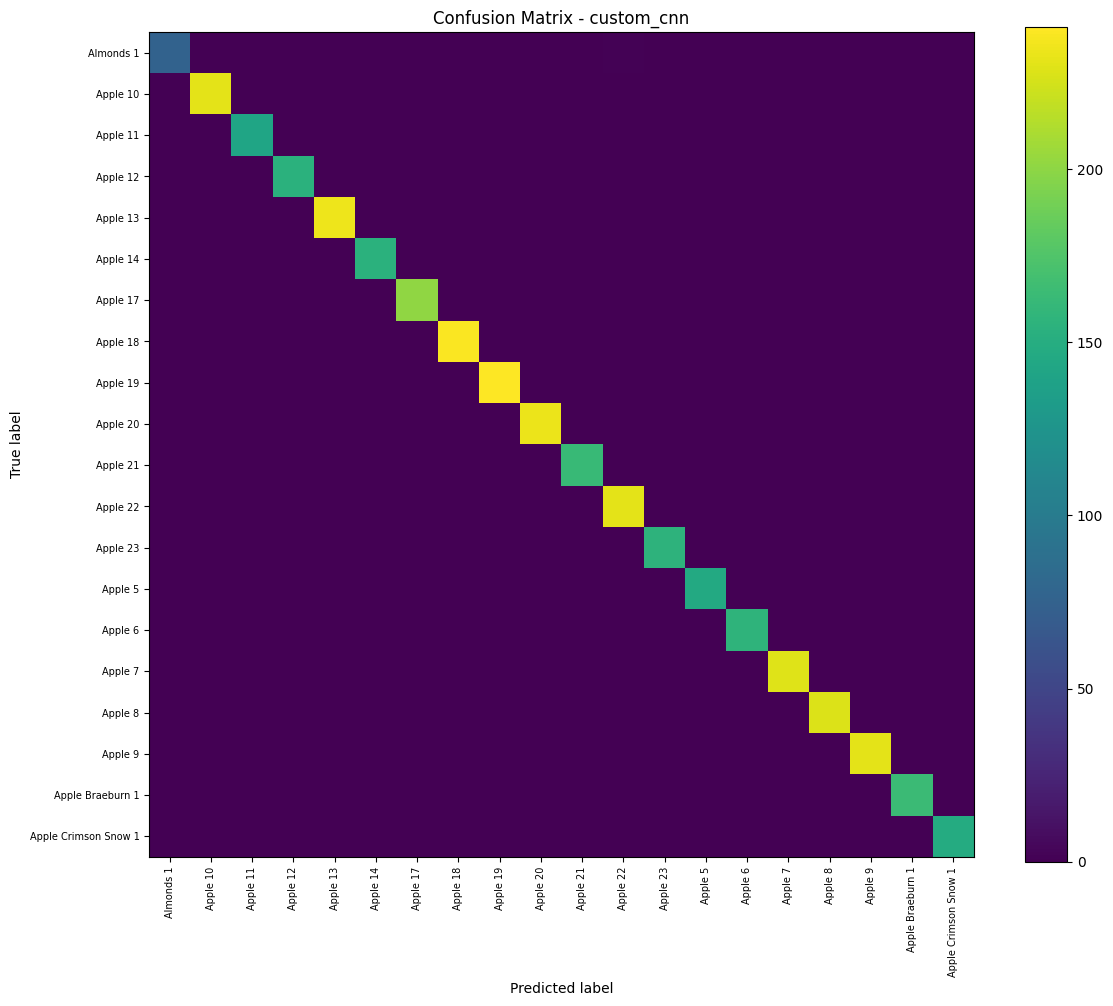

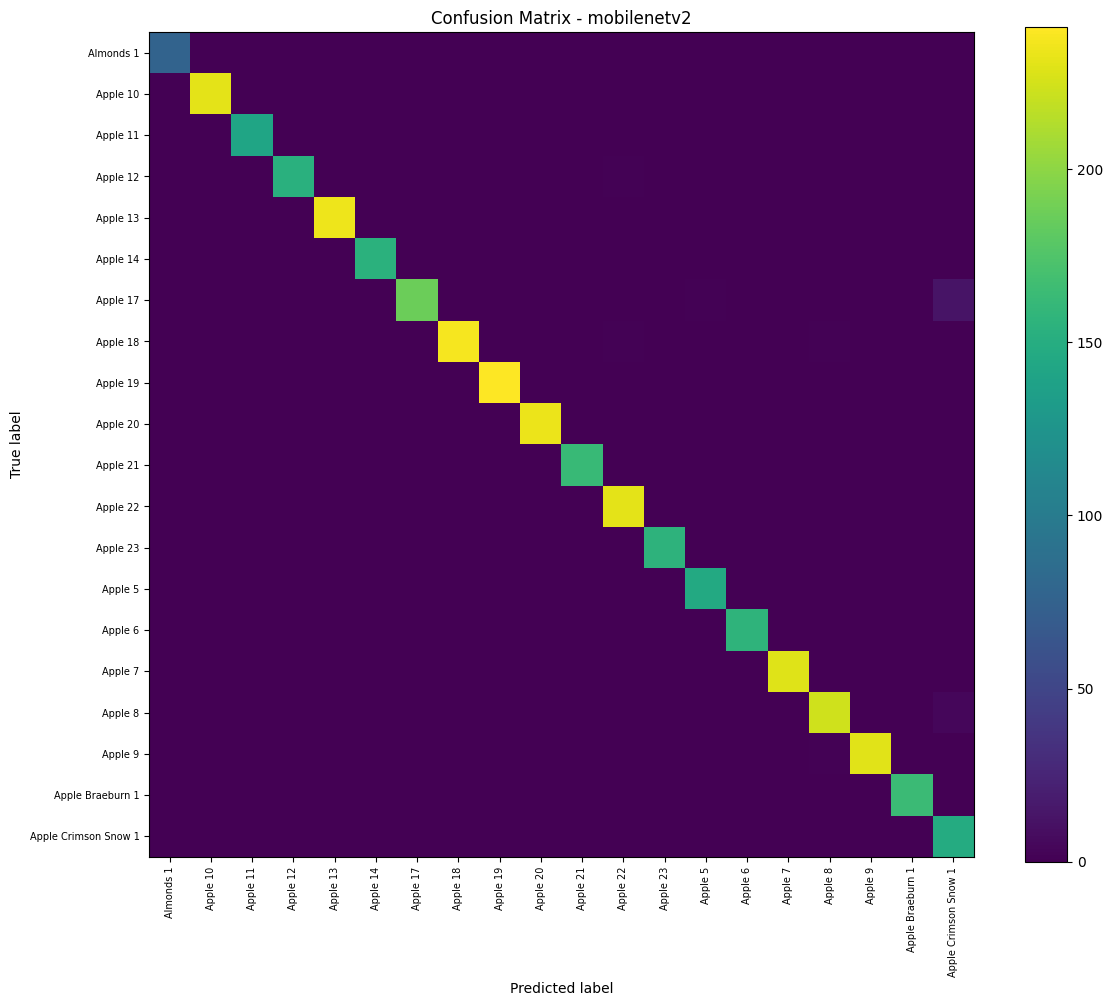


MODEL COMPARISON RESULTS
          model  test_loss  accuracy  precision_weighted  recall_weighted  \
1    custom_cnn   0.003357  0.999734            0.999735         0.999734   
2   mobilenetv2   0.024250  0.994151            0.994618         0.994150   
0  baseline_cnn   0.338056  0.874501            0.883360         0.874501   

   f1_weighted  
1     0.999734  
2     0.994202  
0     0.872533  


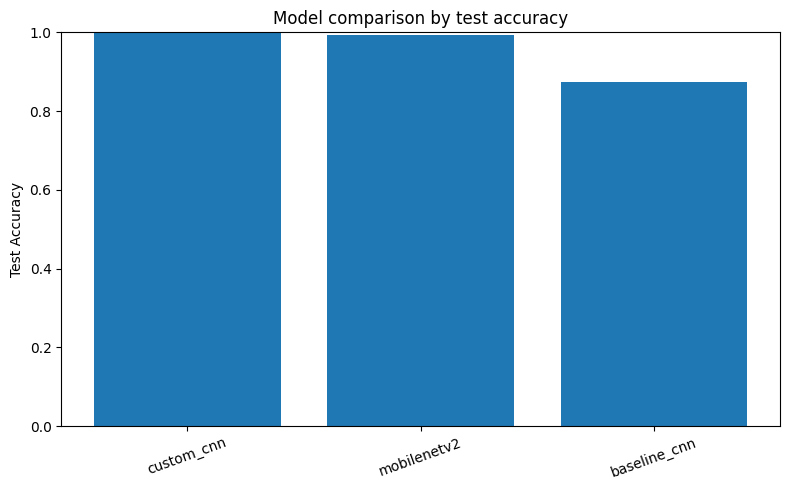

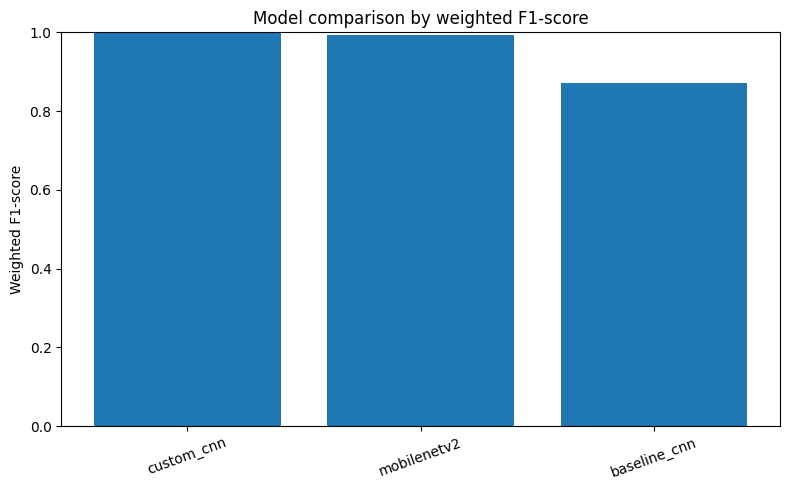

In [16]:

# =========================================================
# 10. DANH GIA VA SO SANH 3 MO HINH
# =========================================================
results = []
results.append(evaluate_and_save(baseline_cnn, 'baseline_cnn'))
results.append(evaluate_and_save(custom_cnn, 'custom_cnn'))
results.append(evaluate_and_save(mobilenetv2, 'mobilenetv2'))

results_df = pd.DataFrame(results).sort_values(by='f1_weighted', ascending=False)
results_df.to_csv(REPORT_DIR / 'model_comparison_results.csv', index=False)

print('\nMODEL COMPARISON RESULTS')
print(results_df)

plt.figure(figsize=(8, 5))
plt.bar(results_df['model'], results_df['accuracy'])
plt.ylim(0, 1)
plt.ylabel('Test Accuracy')
plt.title('Model comparison by test accuracy')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_comparison_accuracy.png', dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(results_df['model'], results_df['f1_weighted'])
plt.ylim(0, 1)
plt.ylabel('Weighted F1-score')
plt.title('Model comparison by weighted F1-score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_comparison_f1.png', dpi=200)
plt.show()

In [17]:


best_model_name = str(results_df.iloc[0]['model'])
experiment_summary = {
    'dataset_kaggle_url': 'https://www.kaggle.com/datasets/moltean/fruits',
    'dataset_root_detected': str(DATA_ROOT),
    'num_original_classes': len(all_classes),
    'num_selected_classes': NUM_CLASSES,
    'selected_classes': selected_classes,
    'best_model_by_weighted_f1': best_model_name,
    'results': results_df.to_dict(orient='records'),
}

with open(REPORT_DIR / 'experiment_summary.json', 'w', encoding='utf-8') as f:
    json.dump(experiment_summary, f, ensure_ascii=False, indent=2)
